# Logic Oasis XGBoost Training and Validation

This notebook trains and validates the XGBoost model used by the Logic Oasis Grey Box AI pipeline.

The trained model predicts immediate student mastery risk from quiz attempt features. SHAP is then used to explain the prediction. BKT is still calculated in the AI pipeline to update long-term mastery probability over time.

Expected output:
- XGBoost validation results
- SHAP explanation plots
- Feature importance ranking
- Saved model bundle: `xgboost_logic_oasis_model.pkl`

## 1. Import Libraries

In [2]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from xgboost import XGBClassifier

RANDOM_STATE = 42
DATA_PATH = Path("quiz_attempts_training_data.csv")
MODEL_PATH = Path("xgboost_logic_oasis_model.pkl")

C:\Users\zyonn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Define Shared Pipeline Schema

These feature names must match `ai_pipeline/modeling.py`. Keeping the same schema prevents the notebook model and Firestore AI pipeline from using different calculations.

In [3]:
FEATURE_NAMES = [
    "score",
    "averageScore",
    "correctRate",
    "wrongCount",
    "averageWrongCount",
    "timeTakenSeconds",
    "averageTimeTakenSeconds",
    "retryCount",
    "difficultyLevel",
    "attemptsCount",
    "scoreChange",
    "scoreConsistency",
    "recentTrend",
    "bktMasteryProbability",
]

LABEL_MAP = {"Weak": 0, "Moderate": 1, "Strong": 2}
LABEL_NAMES = ["Weak", "Moderate", "Strong"]
BASE_FEATURE_NAMES = [
    "score",
    "averageScore",
    "correctRate",
    "wrongCount",
    "timeTakenSeconds",
    "retryCount",
    "difficultyLevel",
    "attemptsCount",
    "recentTrend",
    "bktMasteryProbability",
]

## 3. Load Dataset

For FYP1, the notebook can train from a CSV export named `quiz_attempts_training_data.csv`. If the CSV is not available yet, this notebook creates a small demonstration dataset so the training flow can still be tested.

In [4]:
def add_derived_features(dataframe):
    df = dataframe.copy()
    if "averageWrongCount" not in df.columns:
        df["averageWrongCount"] = df["wrongCount"]
    if "averageTimeTakenSeconds" not in df.columns:
        df["averageTimeTakenSeconds"] = df["timeTakenSeconds"]
    if "scoreChange" not in df.columns:
        trend_step = df["recentTrend"].map({-1: -8, 0: 0, 1: 8}).fillna(0)
        df["scoreChange"] = trend_step
    if "scoreConsistency" not in df.columns:
        df["scoreConsistency"] = (df["score"] - df["averageScore"]).abs()
    return df


def create_demo_training_data():
    rows = []
    demo_rows = [
        (35, 40, 0.35, 5, 260, 3, 1, 3, -1, 0.32, "Weak"),
        (42, 45, 0.40, 4, 240, 2, 1, 4, -1, 0.38, "Weak"),
        (48, 44, 0.45, 4, 230, 2, 2, 5, 0, 0.41, "Weak"),
        (30, 38, 0.30, 6, 280, 3, 2, 4, -1, 0.28, "Weak"),
        (50, 49, 0.50, 4, 210, 2, 1, 5, 0, 0.43, "Weak"),
        (45, 46, 0.45, 4, 220, 2, 1, 3, -1, 0.39, "Weak"),
        (55, 58, 0.55, 3, 190, 1, 1, 4, 0, 0.55, "Moderate"),
        (62, 60, 0.60, 2, 170, 1, 1, 5, 1, 0.61, "Moderate"),
        (68, 64, 0.65, 2, 160, 1, 2, 4, 1, 0.66, "Moderate"),
        (58, 57, 0.55, 3, 180, 1, 1, 3, 0, 0.52, "Moderate"),
        (70, 68, 0.70, 2, 155, 0, 1, 5, 1, 0.70, "Moderate"),
        (64, 62, 0.60, 2, 165, 1, 1, 4, 0, 0.63, "Moderate"),
        (82, 80, 0.80, 1, 120, 0, 1, 5, 1, 0.78, "Strong"),
        (88, 84, 0.85, 1, 105, 0, 1, 6, 1, 0.84, "Strong"),
        (90, 88, 0.90, 0, 95, 0, 2, 5, 1, 0.88, "Strong"),
        (78, 82, 0.78, 1, 130, 0, 1, 4, 0, 0.79, "Strong"),
        (92, 90, 0.92, 0, 85, 0, 2, 6, 1, 0.91, "Strong"),
        (85, 86, 0.85, 1, 110, 0, 1, 5, 0, 0.86, "Strong"),
    ]
    for index, row in enumerate(demo_rows, start=1):
        rows.append(dict(zip(BASE_FEATURE_NAMES + ["masteryLabel"], row)))
    return add_derived_features(pd.DataFrame(rows))

if DATA_PATH.exists():
    df = add_derived_features(pd.read_csv(DATA_PATH))
else:
    df = create_demo_training_data()
    print("quiz_attempts_training_data.csv was not found, so demo data is used for notebook testing.")

df.head()

quiz_attempts_training_data.csv was not found, so demo data is used for notebook testing.


,score,averageScore,correctRate,wrongCount,timeTakenSeconds,retryCount,difficultyLevel,attemptsCount,recentTrend,bktMasteryProbability,masteryLabel
0,35,40,0.35,5,260,3,1,3,-1,0.32,Weak
1,42,45,0.40,4,240,2,1,4,-1,0.38,Weak
2,48,44,0.45,4,230,2,2,5,0,0.41,Weak
3,30,38,0.30,6,280,3,2,4,-1,0.28,Weak
4,50,49,0.50,4,210,2,1,5,0,0.43,Weak


## 4. Clean and Validate Dataset

In [5]:
missing_columns = [name for name in FEATURE_NAMES + ["masteryLabel"] if name not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df = df.copy()
for name in FEATURE_NAMES:
    df[name] = pd.to_numeric(df[name], errors="coerce")

df["masteryLabel"] = df["masteryLabel"].astype(str).str.strip()
df = df.dropna(subset=FEATURE_NAMES + ["masteryLabel"])
df = df[df["masteryLabel"].isin(LABEL_MAP.keys())]

print(df["masteryLabel"].value_counts())
df.describe()

masteryLabel
Weak        6
Moderate    6
Strong      6
Name: count, dtype: int64


,score,averageScore,correctRate,wrongCount,timeTakenSeconds,retryCount,difficultyLevel,attemptsCount,recentTrend,bktMasteryProbability
count,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000
mean,63.444444,63.388889,0.622222,2.500000,172.500000,1.055556,1.277778,4.444444,0.166667,0.607778
std,19.491242,17.809908,0.194922,1.723539,58.567457,1.055642,0.460889,0.921777,0.785905,0.207068
min,30.000000,38.000000,0.300000,0.000000,85.000000,0.000000,1.000000,3.000000,-1.000000,0.280000
25%,48.500000,46.750000,0.462500,1.000000,122.500000,0.000000,1.000000,4.000000,0.000000,0.415000
50%,63.000000,61.000000,0.600000,2.000000,167.500000,1.000000,1.000000,4.500000,0.000000,0.620000
75%,81.000000,81.500000,0.795000,4.000000,217.500000,2.000000,1.750000,5.000000,1.000000,0.787500
max,92.000000,90.000000,0.920000,6.000000,280.000000,3.000000,2.000000,6.000000,1.000000,0.910000


## 5. Prepare Features and Labels

In [6]:
X = df[FEATURE_NAMES]
y = df["masteryLabel"].map(LABEL_MAP)

if y.nunique() < 2:
    raise ValueError("Training requires at least two mastery classes, such as Weak and Moderate.")

## 6. Train and Test Split

In [7]:
class_counts = y.value_counts()
can_stratify = class_counts.min() >= 2

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y if can_stratify else None,
)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Training rows: 13
Testing rows: 5


### 6.1 Inspect Train/Test Data

In [8]:
LABEL_BY_INDEX = {value: key for key, value in LABEL_MAP.items()}

print("Feature matrix sizes")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nTraining label balance")
print(y_train.map(LABEL_BY_INDEX).value_counts())

print("\nTesting label balance")
print(y_test.map(LABEL_BY_INDEX).value_counts())

train_preview = X_train.copy()
train_preview["masteryLabel"] = y_train.map(LABEL_BY_INDEX)

test_preview = X_test.copy()
test_preview["masteryLabel"] = y_test.map(LABEL_BY_INDEX)

display(train_preview.head(10))
display(test_preview.head(10))

Feature matrix sizes
X_train: (13, 10)
X_test: (5, 10)
y_train: (13,)
y_test: (5,)

Training label balance
masteryLabel
Weak        5
Strong      4
Moderate    4
Name: count, dtype: int64

Testing label balance
masteryLabel
Moderate    2
Strong      2
Weak        1
Name: count, dtype: int64


,score,averageScore,correctRate,wrongCount,timeTakenSeconds,retryCount,difficultyLevel,attemptsCount,recentTrend,bktMasteryProbability,masteryLabel
12,82,80,0.80,1,120,0,1,5,1,0.78,Strong
0,35,40,0.35,5,260,3,1,3,-1,0.32,Weak
10,70,68,0.70,2,155,0,1,5,1,0.70,Moderate
6,55,58,0.55,3,190,1,1,4,0,0.55,Moderate
1,42,45,0.40,4,240,2,1,4,-1,0.38,Weak
17,85,86,0.85,1,110,0,1,5,0,0.86,Strong
3,30,38,0.30,6,280,3,2,4,-1,0.28,Weak
13,88,84,0.85,1,105,0,1,6,1,0.84,Strong
14,90,88,0.90,0,95,0,2,5,1,0.88,Strong
11,64,62,0.60,2,165,1,1,4,0,0.63,Moderate


,score,averageScore,correctRate,wrongCount,timeTakenSeconds,retryCount,difficultyLevel,attemptsCount,recentTrend,bktMasteryProbability,masteryLabel
8,68,64,0.65,2,160,1,2,4,1,0.66,Moderate
7,62,60,0.60,2,170,1,1,5,1,0.61,Moderate
4,50,49,0.50,4,210,2,1,5,0,0.43,Weak
15,78,82,0.78,1,130,0,1,4,0,0.79,Strong
16,92,90,0.92,0,85,0,2,6,1,0.91,Strong


## 7. Train XGBoost Model

In [9]:
model = XGBClassifier(
    n_estimators=80,
    max_depth=3,
    learning_rate=0.1,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import l

## 8. Validate Model

In [10]:
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred, labels=[0, 1, 2], target_names=LABEL_NAMES, zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred, labels=[0, 1, 2]))

Accuracy: 0.8
              precision    recall  f1-score   support

        Weak       1.00      1.00      1.00         1
    Moderate       0.67      1.00      0.80         2
      Strong       1.00      0.50      0.67         2

    accuracy                           0.80         5
   macro avg       0.89      0.83      0.82         5
weighted avg       0.87      0.80      0.79         5

Confusion matrix:
[[1 0 0]
 [0 2 0]
 [0 1 1]]


## 9. Cross Validation

Cross validation gives a more stable validation result when there is enough labelled data. For a very small FYP demo dataset, this cell will reduce the number of folds automatically.

In [11]:
min_class_count = int(y.value_counts().min())
if min_class_count >= 2:
    n_splits = min(3, min_class_count)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    print("Cross validation accuracy scores:", cv_scores)
    print("Mean CV accuracy:", round(cv_scores.mean(), 4))
else:
    print("Not enough rows per class for cross validation yet.")

Cross validation accuracy scores: [1.  0.5 1. ]
Mean CV accuracy: 0.8333


## 10. SHAP Explainability

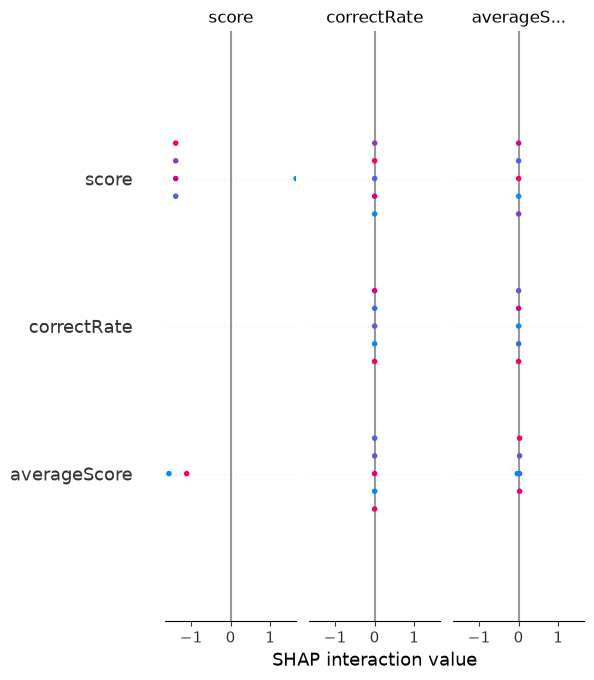

In [12]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=FEATURE_NAMES)

## 11. Single Prediction Explanation

In [26]:
sample_index = 0
sample = X_test.iloc[[sample_index]]
prediction = int(model.predict(sample)[0])
prediction_probability = model.predict_proba(sample)[0]

print("Prediction:", LABEL_NAMES[prediction])
print("Weak probability:", round(float(prediction_probability[LABEL_MAP["Weak"]]), 4))
print("Confidence:", round(float(prediction_probability.max()), 4))
sample

Prediction: Moderate
Weak probability: 0.0689
Confidence: 0.8655


,score,averageScore,correctRate,wrongCount,timeTakenSeconds,retryCount,difficultyLevel,attemptsCount,recentTrend,bktMasteryProbability
8,68,64,0.65,2,160,1,2,4,1,0.66


### 11.1 Top SHAP Reasons for the Selected Sample

In [ ]:
def shap_values_for_sample_class(shap_values, row_index, class_index):
    values = np.array(shap_values)

    if isinstance(shap_values, list):
        return np.array(shap_values[class_index][row_index])

    if values.ndim == 3:
        if values.shape[0] == len(X_test):
            return values[row_index, :, class_index]
        return values[class_index, row_index, :]

    return values[row_index]


def print_top_shap_reasons(row_index, top_n=3):
    sample = X_test.iloc[[row_index]]
    prediction = int(model.predict(sample)[0])
    prediction_probability = model.predict_proba(sample)[0]
    selected_values = shap_values_for_sample_class(shap_values, row_index, prediction)

    reason_table = pd.DataFrame(
        {
            "feature": FEATURE_NAMES,
            "value": sample.iloc[0].values,
            "shap_value": selected_values,
            "impact_size": np.abs(selected_values),
        }
    ).sort_values("impact_size", ascending=False)

    print(f"Sample index: {row_index}")
    print("Prediction:", LABEL_NAMES[prediction])
    print("Weak probability:", round(float(prediction_probability[LABEL_MAP["Weak"]]), 4))
    print("Confidence:", round(float(prediction_probability.max()), 4))
    print("Top SHAP features that influenced this prediction:")

    for rank, (_, row) in enumerate(reason_table.head(top_n).iterrows(), start=1):
        direction = "increased" if row["shap_value"] > 0 else "reduced"
        print(
            f"{rank}. {row['feature']} = {row['value']} "
            f"({direction} support for {LABEL_NAMES[prediction]}, "
            f"SHAP={row['shap_value']:.4f})"
        )

    display(reason_table.head(top_n)[["feature", "value", "shap_value"]])


for index in range(min(3, len(X_test))):
    print_top_shap_reasons(index)
    print("-" * 72)

## 12. Feature Importance

In [14]:
importance = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "importance": model.feature_importances_,
}).sort_values(by="importance", ascending=False)

importance

,feature,importance
0,score,0.916829
1,averageScore,0.044582
7,attemptsCount,0.038588
2,correctRate,0.000000
4,timeTakenSeconds,0.000000
3,wrongCount,0.000000
5,retryCount,0.000000
6,difficultyLevel,0.000000
8,recentTrend,0.000000
9,bktMasteryProbability,0.000000


## 13. Save Model Bundle

The AI pipeline can use this saved bundle when `run_ai_pipeline.py` is executed.

In [15]:
model_bundle = {
    "model": model,
    "features": FEATURE_NAMES,
    "label_map": LABEL_MAP,
    "label_names": LABEL_NAMES,
}

joblib.dump(model_bundle, MODEL_PATH)
print(f"Saved model bundle to {MODEL_PATH.resolve()}")

Saved model bundle to C:\Users\zyonn\Documents\FYP\logic_oasis\ai_pipeline\xgboost_logic_oasis_model.pkl


## 14. BKT Integration Note

XGBoost predicts the immediate weakness or risk level from engineered quiz features.

BKT is applied after the quiz attempt sequence is read by `run_ai_pipeline.py`. BKT updates long-term mastery probability using prior knowledge, learn rate, guess rate, and slip rate.

The final Logic Oasis mastery label is therefore produced by combining:
- XGBoost immediate prediction
- SHAP explanation
- BKT long-term mastery probability